In [59]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("acon96/Home-Assistant-Requests")
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

In [60]:
display(df_train.head())
display(df_test.head())

,conversations
0,"[{'from': 'system', 'value': 'You are 'Al', a ..."
1,"[{'from': 'system', 'value': 'You are 'Al', a ..."
2,"[{'from': 'system', 'value': 'You are 'Al', a ..."
3,"[{'from': 'system', 'value': 'You are 'Al', a ..."
4,"[{'from': 'system', 'value': 'You are 'Al', a ..."


,conversations
0,"[{'from': 'system', 'value': 'You are 'Al', a ..."
1,"[{'from': 'system', 'value': 'You are 'Al', a ..."
2,"[{'from': 'system', 'value': 'You are 'Al', a ..."
3,"[{'from': 'system', 'value': 'You are 'Al', a ..."
4,"[{'from': 'system', 'value': 'You are 'Al', a ..."


In [61]:
def extract_action_type(conversation_list):
    text = str(conversation_list)
    # Basic logic to find the service call within the generated text block
    if '"service":' in text:
        return "Home Assistant Service Call"
    return "Standard Conversational Reply"

df_train['action_type'] = df_train['conversations'].apply(extract_action_type)
df_test['action_type'] = df_test['conversations'].apply(extract_action_type)

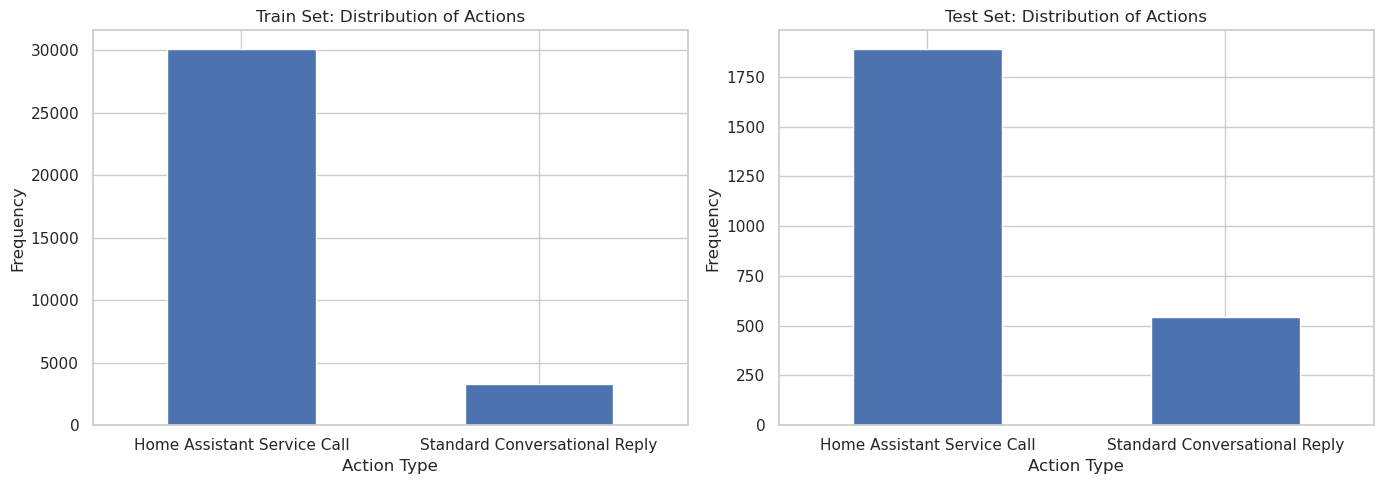

In [62]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['action_type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Train Set: Distribution of Actions')
axes[0].set_xlabel('Action Type')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=0)

df_test['action_type'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Set: Distribution of Actions')
axes[1].set_xlabel('Action Type')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [72]:
import json
import re

def extract_data(data_split):
    domains = []
    services = []
    entities = []
    for row in data_split:
        conversations = row.get("conversations", [])
        for turn in conversations:
            # We only care about the assistant's outputs
            if turn.get("from") == "assistant":
                text = turn.get("value", "")
                match = re.search(r'```homeassistant\n(.*?)\n```', text, re.DOTALL)
                if match:
                    json_str = match.group(1)
                else:
                    continue

                try:
                    payload = json.loads(json_str)
                    service_call = payload.get("service", "")
                    if "." in service_call:
                        domain = service_call.split(".")[0]
                        domains.append(domain)
                        services.append(service_call)

                    entity_id = payload.get("target_device")
                    if isinstance(entity_id, str):
                        entities.append(entity_id)
                    elif isinstance(entity_id, list):
                        entities.extend(entity_id)
                except json.JSONDecodeError:
                    pass # Skip improperly formatted JSON
    return domains, services, entities

train_domains, train_services, train_entities = extract_data(dataset["train"])
test_domains, test_services, test_entities = extract_data(dataset["test"])

def get_items(items_list):
    if not items_list: return pd.Series(dtype='float64')
    return pd.Series(items_list).value_counts()#.head(10)

dom_train = get_items(train_domains)
svc_train = get_items(train_services)
ent_train = get_items(train_entities)

dom_test = get_items(test_domains)
svc_test = get_items(test_services)
ent_test = get_items(test_entities)

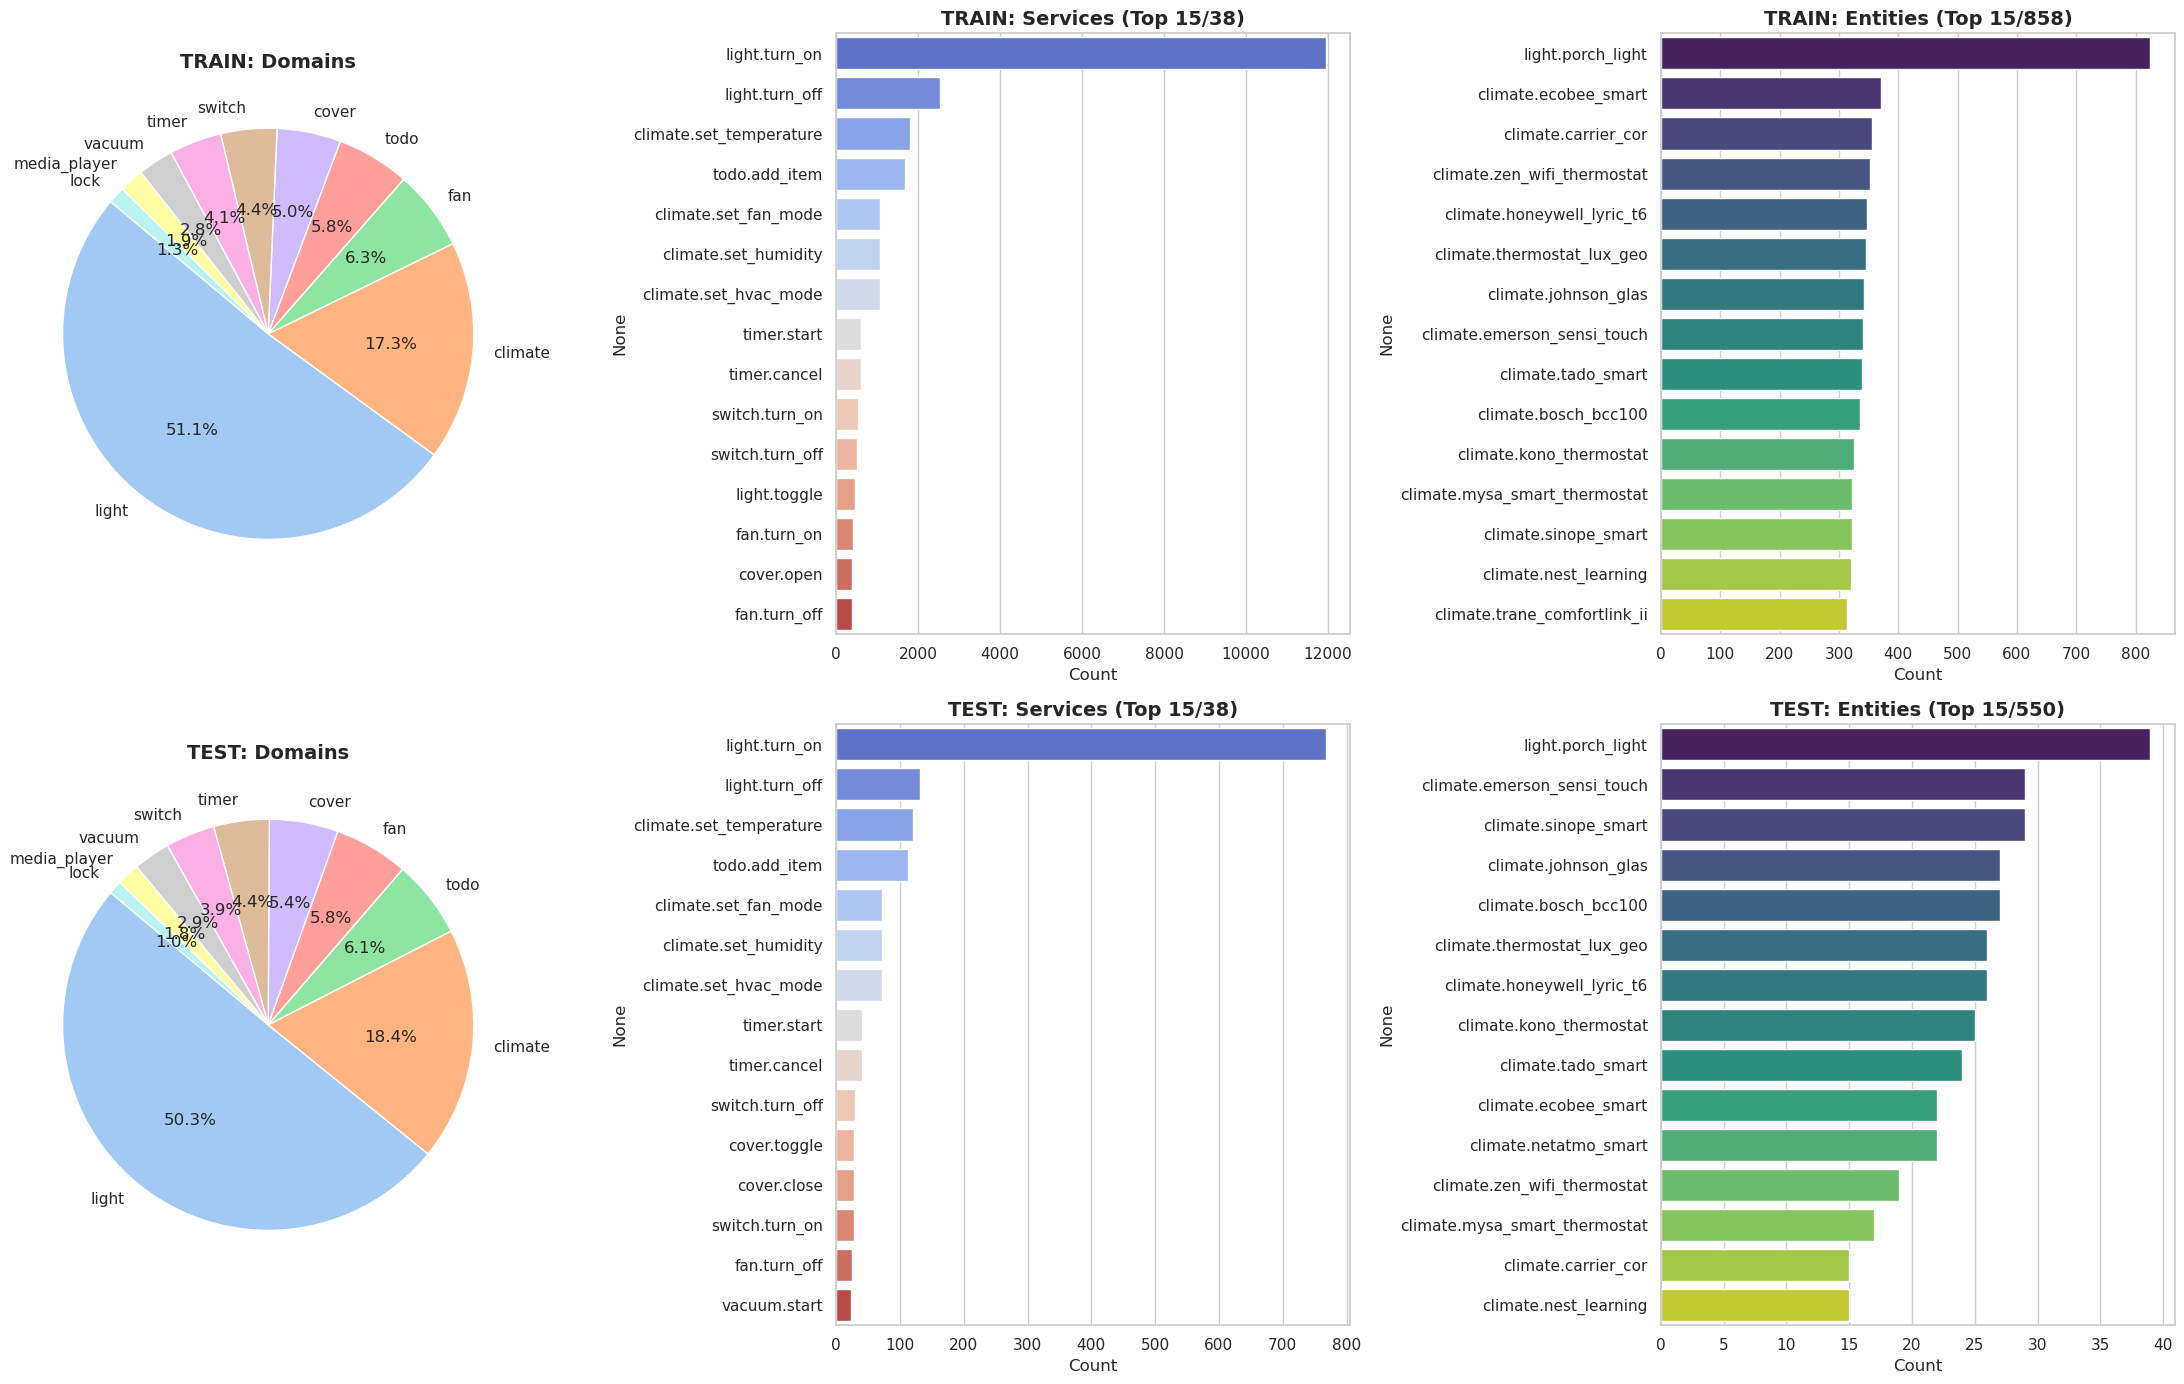

In [75]:
import seaborn as sns

PLOT_LIMIT = 15
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(22, 14)) # change figsize 2nd param to make space for additional bars

def plot_bar_safe(data, ax, title, color_palette="viridis", limit=PLOT_LIMIT):
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center')
        return
    # Prendiamo solo i top N per il grafico
    subset = data.head(limit)
    sns.barplot(x=subset.values, y=subset.index, ax=ax, palette=color_palette, hue=subset.index, legend=False)
    ax.set_title(f"{title} (Top {limit}/{len(data)})", fontsize=14, fontweight='bold')
    ax.set_xlabel('Count')

def plot_pie_safe(data, ax, title):
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center')
        return
    # Se sono troppi per una torta, ne mostriamo solo 15 + "Others"
    if len(data) > 15:
        top_slice = data.head(15)
        others = pd.Series([data.iloc[15:].sum()], index=['Others'])
        data_to_plot = pd.concat([top_slice, others])
    else:
        data_to_plot = data

    ax.pie(data_to_plot.values, labels=data_to_plot.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    ax.set_title(title, fontsize=14, fontweight='bold')

plot_pie_safe(dom_train, axes[0, 0], 'TRAIN: Domains')
plot_bar_safe(svc_train, axes[0, 1], 'TRAIN: Services', "coolwarm")
plot_bar_safe(ent_train, axes[0, 2], 'TRAIN: Entities', "viridis")

plot_pie_safe(dom_test, axes[1, 0], 'TEST: Domains')
plot_bar_safe(svc_test, axes[1, 1], 'TEST: Services', "coolwarm")
plot_bar_safe(ent_test, axes[1, 2], 'TEST: Entities', "viridis")

plt.tight_layout()
plt.show()

In [77]:
# 1. Exporting the aggregated "top 10" lists you created
# We give the columns proper headers so Excel knows what it is looking at.
dom_train.to_csv("./data/domains_train.csv", header=["Count"], index_label="Domain")
svc_train.to_csv("./data/services_train.csv", header=["Count"], index_label="Service")
ent_train.to_csv("./data/entities_train.csv", header=["Count"], index_label="Entity")

dom_test.to_csv("./data/domains_test.csv", header=["Count"], index_label="Domain")
svc_test.to_csv("./data/services_test.csv", header=["Count"], index_label="Service")
ent_test.to_csv("./data/entities_test.csv", header=["Count"], index_label="Entity")

# 2. Exporting the raw lists for deep exploration in Excel (Pivot Tables, etc.)
# Wrapping them in pd.Series() first prevents fatal errors if your entity lists
# are a different length than your domains due to your 'extend' logic.
df_raw_train = pd.DataFrame({
    "Domain": pd.Series(train_domains),
    "Service": pd.Series(train_services),
    "Entity": pd.Series(train_entities)
})
df_raw_train.to_csv("./data/cleaned_raw_train.csv", index=False)

df_raw_test = pd.DataFrame({
    "Domain": pd.Series(test_domains),
    "Service": pd.Series(test_services),
    "Entity": pd.Series(test_entities)
})
df_raw_test.to_csv("./data/cleaned_raw_test.csv", index=False)